# Coding Task: Hoeffding’s Inequality Simulation

**Goal:** Demonstrate that with more training data, the out‑of‑sample error ($E_{\text{out}}$) converges to the in‑sample error ($E_{\text{in}}$), as predicted by Hoeffding’s Inequality.

## What You Will Do

- For different training set sizes $N_{\text{train}} = [5, 10, 20, 50, 100, 200, 500]$:
  1. Train PLA on $N_{\text{train}}$ random points (from the same distribution as in Task 1).
  2. Compute $E_{\text{in}}$ (training error).
  3. Compute $E_{\text{out}}$ (test error on 1000 fresh points).
  4. Repeat **10 times** for each $N_{\text{train}}$ to average out randomness.
- Plot:
  - Average $E_{\text{in}}$ and $E_{\text{out}}$ vs. $N_{\text{train}}$.
  - Generalization gap $|E_{\text{out}} - E_{\text{in}}|$ vs. $N_{\text{train}}$.
  - Overlay the Hoeffding bound $2e^{-2\epsilon^2 N}$ for $\epsilon = 0.1$.
- Compare your PLA with scikit‑learn’s `Perceptron`.

## Questions to Answer (at the end)

1. Does the gap $|E_{\text{out}} - E_{\text{in}}|$ shrink as $N_{\text{train}}$ increases?
2. At what $N_{\text{train}}$ does the Hoeffding bound become $\leq 0.05$?
3. Does the actual gap stay below the bound? Why or why not?
4. How does the scikit‑learn Perceptron compare to your PLA?

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Perceptron

# ---------- Data generation (same as Task 1) ----------
def generate_data(N, true_w, x_range=(-5,5)):
    X = np.random.uniform(x_range[0], x_range[1], (N, 2))
    X_aug = np.c_[np.ones(N), X]   # add bias column
    y = np.sign(X_aug @ true_w)
    y[y == 0] = 1
    return X_aug, y

# True line: x2 = 0.5*x1 + 1  -> w0=2, w1=1, w2=-2
true_w = np.array([2.0, 1.0, -2.0])

In [2]:
def pla(X, y, max_iter=1000):
    w = np.zeros(X.shape[1])
    for it in range(max_iter):
        mis = False
        for i in range(len(y)):
            if np.sign(X[i] @ w) != y[i]:
                w = w + y[i] * X[i]
                mis = True
                break
        if not mis:
            return w, it+1
    return w, max_iter

def predict(w, X):
    return np.sign(X @ w)

def error(w, X, y):
    return np.mean(predict(w, X) != y)

In [3]:
def run_hoeffding_simulation(train_sizes, num_repeats=10, test_size=1000):
    avg_ein = []
    avg_eout = []
    avg_gap = []
    
    for Ntrain in train_sizes:
        ein_list = []
        eout_list = []
        gap_list = []
        
        for _ in range(num_repeats):
            # Generate training data of size Ntrain
            X_train_aug, y_train = generate_data(Ntrain, true_w)
            # Train PLA
            w, _ = pla(X_train_aug, y_train)
            # Compute Ein
            ein = error(w, X_train_aug, y_train)
            # Generate fresh test data
            X_test_aug, y_test = generate_data(test_size, true_w)
            # Compute Eout
            eout = error(w, X_test_aug, y_test)
            
            ein_list.append(ein)
            eout_list.append(eout)
            gap_list.append(abs(eout - ein))
        
        avg_ein.append(np.mean(ein_list))
        avg_eout.append(np.mean(eout_list))
        avg_gap.append(np.mean(gap_list))
    
    return avg_ein, avg_eout, avg_gap

train_sizes = [5, 10, 20, 50, 100, 200, 500]
avg_ein, avg_eout, avg_gap = run_hoeffding_simulation(train_sizes, num_repeats=10)

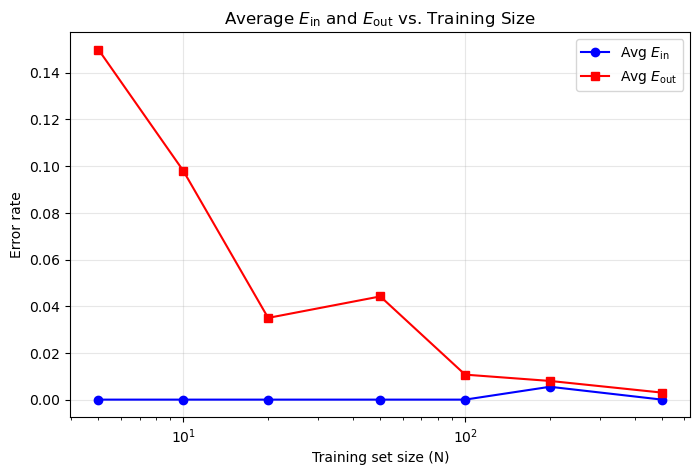

In [7]:
# Cell 4: Plot avg Ein and Eout
plt.figure(figsize=(8,5))
plt.plot(train_sizes, avg_ein, 'bo-', label='Avg $E_{\\text{in}}$')
plt.plot(train_sizes, avg_eout, 'rs-', label='Avg $E_{\\text{out}}$')
plt.xlabel('Training set size (N)')
plt.ylabel('Error rate')
plt.title('Average $E_{\\text{in}}$ and $E_{\\text{out}}$ vs. Training Size')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xscale('log')
plt.show()

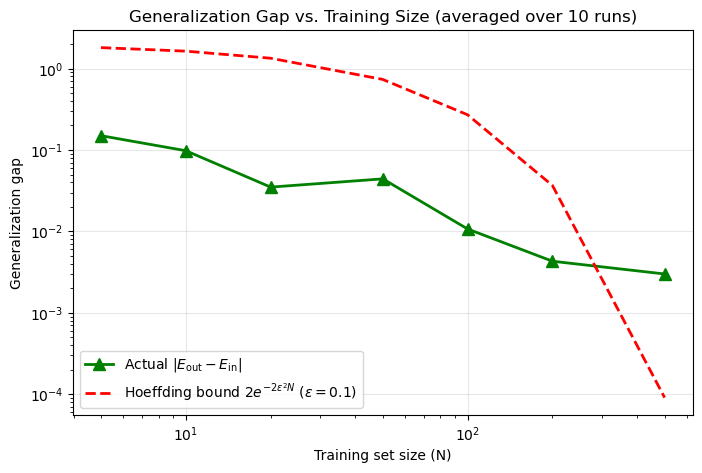

In [15]:
# Cell 5: Generalization gap and Hoeffding bound (epsilon = 0.1)
epsilon = 0.1
hoeffding_bound = [2 * np.exp(-2 * epsilon**2 * N) for N in train_sizes]

plt.figure(figsize=(8,5))
plt.plot(train_sizes, avg_gap, 'g^-', linewidth=2, markersize=8, label='Actual $|E_{\\text{out}} - E_{\\text{in}}|$')
plt.plot(train_sizes, hoeffding_bound, 'r--', linewidth=2, label=f'Hoeffding bound $2e^{{-2\\epsilon^2 N}}$ ($\\epsilon={epsilon}$)')
plt.xlabel('Training set size (N)')
plt.ylabel('Generalization gap')
plt.title('Generalization Gap vs. Training Size (averaged over 10 runs)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xscale('log')
plt.yscale('log')
plt.show()

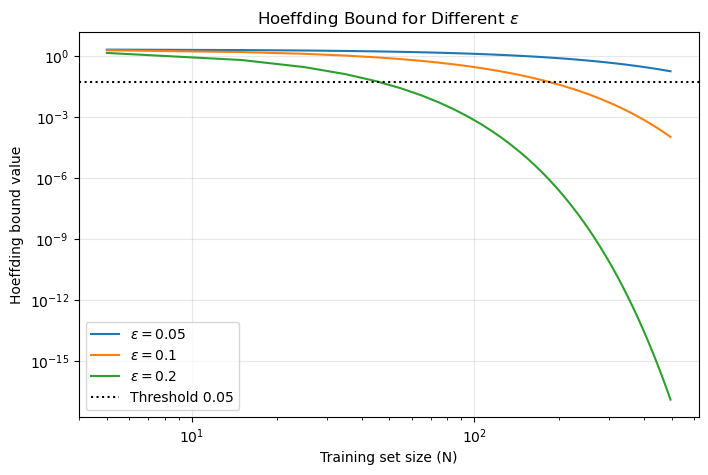

In [11]:
# Cell 6: Compare Hoeffding bounds for different epsilon
epsilons = [0.05, 0.1, 0.2]
N_range = np.arange(5, 501, 10)

plt.figure(figsize=(8,5))
for eps in epsilons:
    bound = [2 * np.exp(-2 * eps**2 * N) for N in N_range]
    plt.plot(N_range, bound, label=f'$\\epsilon = {eps}$')

plt.axhline(y=0.05, color='black', linestyle=':', label='Threshold 0.05')
plt.xlabel('Training set size (N)')
plt.ylabel('Hoeffding bound value')
plt.title('Hoeffding Bound for Different $\\epsilon$')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xscale('log')
plt.yscale('log')
plt.show()

In [ ]:
## Questions to Answer (write your answers below)

1. **Look at the first plot** (average $E_{\text{in}}$ and $E_{\text{out}}$ vs. $N$):
   - What happens to both errors as $N$ increases?
   - Is $E_{\text{in}}$ always smaller than $E_{\text{out}}$? Why?

2. **Look at the second plot** (generalization gap with Hoeffding bound):
   - Does the actual gap $|E_{\text{out}} - E_{\text{in}}|$ decrease with $N$?
   - Does the Hoeffding bound correctly upper‑bound the actual gap?
   - At what $N$ does the bound become $\leq 0.05$? (Read from the plot or compute.)

3. **Look at the third plot** (different $\epsilon$ values):
   - Which $\epsilon$ gives the tightest bound (smallest value)?
   - Why does a larger $\epsilon$ make the bound smaller?